# Perbandingan Metode Imputasi Missing Value terhadap Kinerja Model Klasifikasi Pada Dataset Diabetes

---

| Mata Kuliah | Penambangan Data — Semester Genap |
|---|---|
| Dosen Pengampu | Meida Cahyo Untoro, S.Kom., M.Kom. |
| Kelompok | 05 |
| Topik | Perbandingan Metode Imputasi Missing Value pada Dataset Diabetes |

### Anggota Kelompok

| No | NIM | Nama Lengkap |
|---|---|---|
| 1 | 123140078 | Najlatika |
| 2 | 123140089 | Bening Apni Prameswari |
| 3 | 123140124 | Falent Antonius Panjaitan |
| 4 | 123140125 | Raditya Alrasyid Nugroho |
| 5 | 123140169 | Raisya Syifa Saleh |
| 6 | 123140186 | Muhamad Arif Ardani |

## 1. Pendahuluan

Penambangan data merupakan proses ekstraksi pengetahuan dari dataset yang besar. Salah satu tantangan utama dalam penambangan data adalah menangani **missing value** (nilai yang hilang). Missing value dapat terjadi karena berbagai alasan seperti kesalahan input, perangkat yang tidak bekerja, atau data yang tidak tersedia.

Pada dataset Diabetes Pima Indians, beberapa nilai 0 pada fitur medis tertentu sebenarnya merupakan **missing value tersembunyi** karena tidak masuk akal secara konteks medis. Misalnya, nilai Glucose = 0 tidak mungkin untuk manusia yang hidup.

### Tujuan Project

Project ini bertujuan untuk:
1. Mengidentifikasi dan menangani missing value pada dataset diabetes
2. Membandingkan tiga metode imputasi: **Mean Imputation**, **KNN Imputation**, dan **MICE (Iterative Imputation)**
3. Mengevaluasi dampak setiap metode imputasi terhadap performa model klasifikasi Random Forest
4. Menentukan metode imputasi yang paling efektif

## 2. Persiapan Environment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, RocCurveDisplay, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print("✓ Semua library berhasil dimuat.")

✓ Semua library berhasil dimuat.


## 3. Pemuatan Dataset

In [2]:
df = pd.read_csv('../dataset/diabetes.csv')
print(f"✓ Dataset berhasil dimuat.")
print(f"  Ukuran dataset: {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"\nNama-nama kolom:")
print(df.columns.tolist())

✓ Dataset berhasil dimuat.
  Ukuran dataset: 768 baris × 9 kolom

Nama-nama kolom:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


## 4. Inspeksi Data Awal

In [3]:
print("═" * 60)
print("INFORMASI DATASET AWAL (Sebelum Handling Missing Value)")
print("═" * 60)
print("\n>>> 5 Data Teratas:")
display(df.head())
print("\n>>> Informasi Tipe Data dan Missing Value:")
print(df.info())
print("\n>>> Statistik Deskriptif:")
display(df.describe())
print("\n>>> Jumlah Missing Value (NaN) per Kolom:")
missing_count = df.isnull().sum()
if missing_count.sum() == 0:
    print("  Tidak ada missing value (NaN) yang terdeteksi.")
else:
    display(missing_count[missing_count > 0])

════════════════════════════════════════════════════════════
INFORMASI DATASET AWAL (Sebelum Handling Missing Value)
════════════════════════════════════════════════════════════

>>> 5 Data Teratas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



>>> Informasi Tipe Data dan Missing Value:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

>>> Statistik Deskriptif:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



>>> Jumlah Missing Value (NaN) per Kolom:
  Tidak ada missing value (NaN) yang terdeteksi.


## 5. Identifikasi dan Handling Missing Value Tersembunyi

In [4]:
print("═" * 60)
print("IDENTIFIKASI MISSING VALUE TERSEMBUNYI")
print("═" * 60)
zero_not_allowed = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\n>>> Kolom yang diperiksa (nilai 0 = missing):")
for col in zero_not_allowed:
    count_zeros = (df[col] == 0).sum()
    percentage = (count_zeros / len(df)) * 100
    print(f"  • {col}: {count_zeros} nilai → {percentage:.1f}%")
df[zero_not_allowed] = df[zero_not_allowed].replace(0, np.nan)
print("\n>>> Nilai 0 telah diubah menjadi NaN.")
print("\n>>> Jumlah Missing Value per Kolom (Setelah Konversi):")
missing_after = df.isnull().sum()
missing_after_nonzero = missing_after[missing_after > 0]
missing_percentage = (missing_after_nonzero / len(df)) * 100
missing_summary = pd.DataFrame({
    'Kolom': missing_after_nonzero.index,
    'Jumlah Missing': missing_after_nonzero.values,
    'Persentase': missing_percentage.values
})
display(missing_summary.sort_values('Persentase', ascending=False))

════════════════════════════════════════════════════════════
IDENTIFIKASI MISSING VALUE TERSEMBUNYI
════════════════════════════════════════════════════════════

>>> Kolom yang diperiksa (nilai 0 = missing):
  • Glucose: 5 nilai → 0.7%
  • BloodPressure: 35 nilai → 4.6%
  • SkinThickness: 227 nilai → 29.6%
  • Insulin: 374 nilai → 48.7%
  • BMI: 11 nilai → 1.4%

>>> Nilai 0 telah diubah menjadi NaN.

>>> Jumlah Missing Value per Kolom (Setelah Konversi):


,Kolom,Jumlah Missing,Persentase
3,Insulin,374,48.697917
2,SkinThickness,227,29.557292
1,BloodPressure,35,4.557292
4,BMI,11,1.432292
0,Glucose,5,0.651042


## 6. Eksplorasi Data

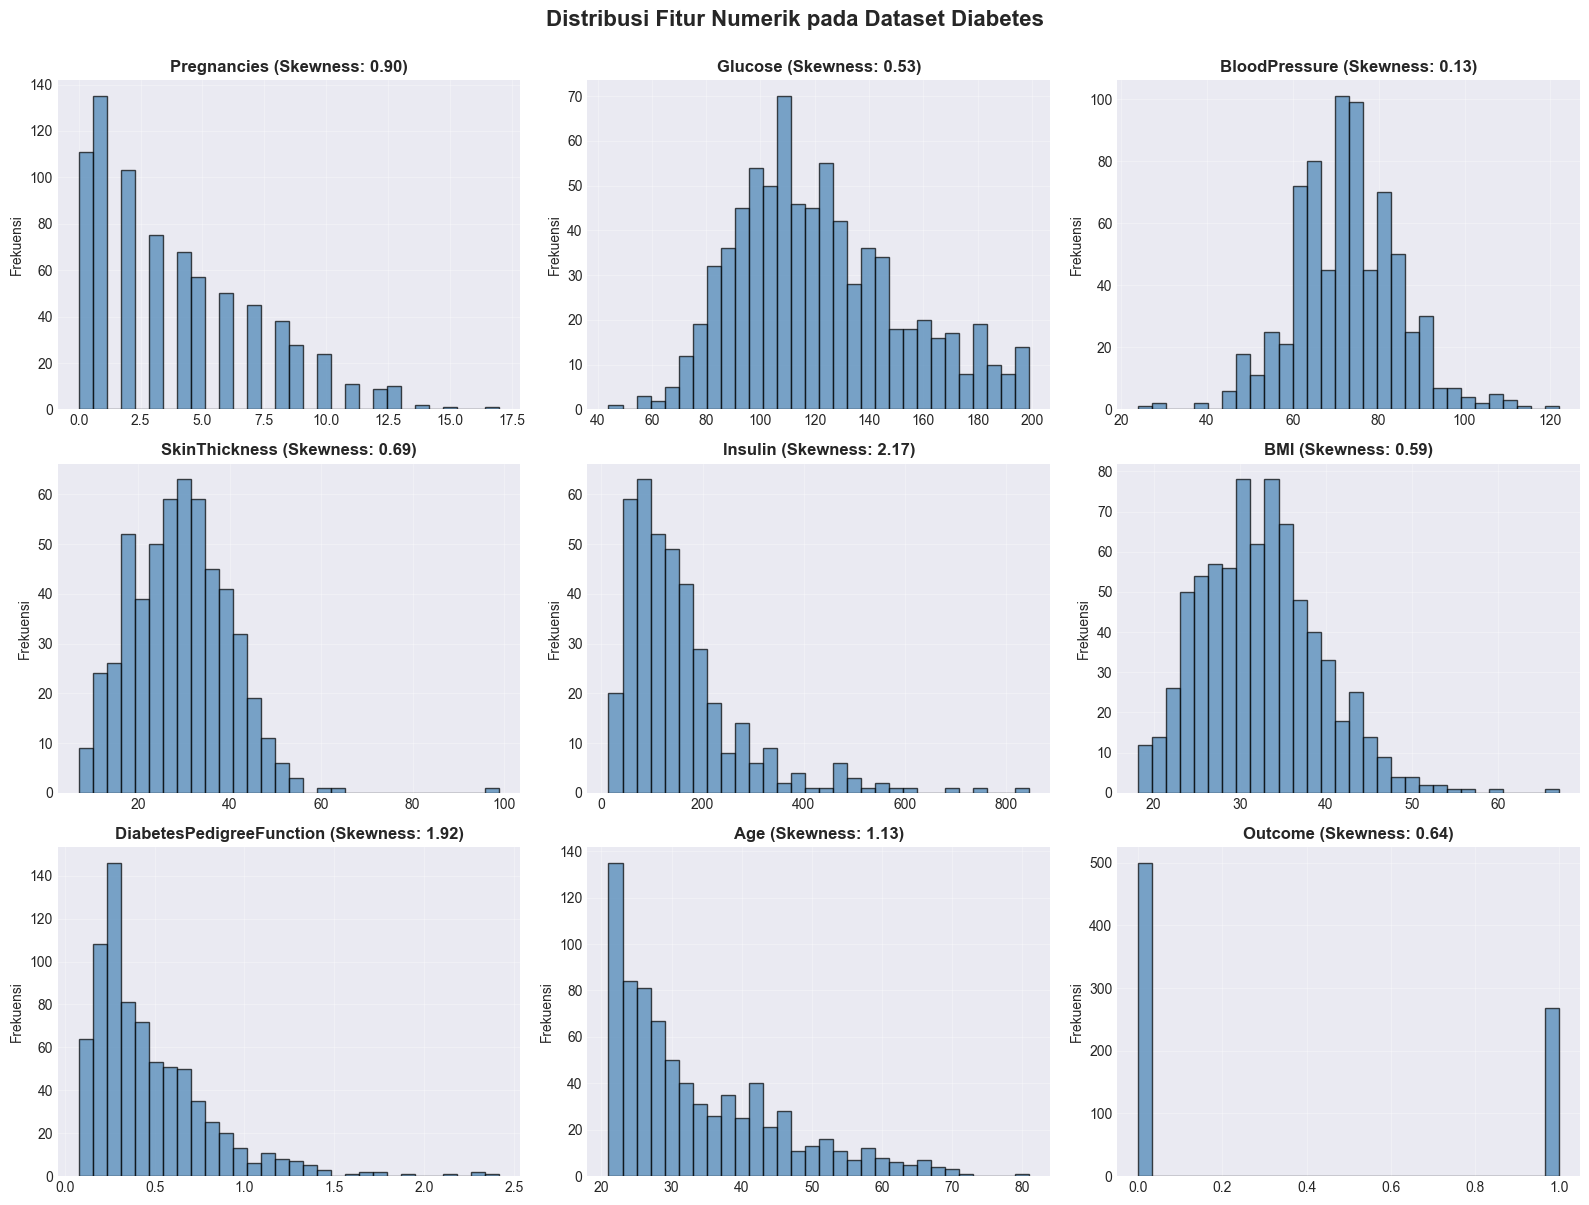

✓ Visualisasi distribusi fitur selesai.


In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, alpha=0.7, edgecolor='black', color='steelblue')
    axes[i].set_title(f'{col} (Skewness: {df[col].skew():.2f})', fontweight='bold')
    axes[i].set_ylabel('Frekuensi')
    axes[i].grid(alpha=0.3)
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik pada Dataset Diabetes', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()
print("✓ Visualisasi distribusi fitur selesai.")

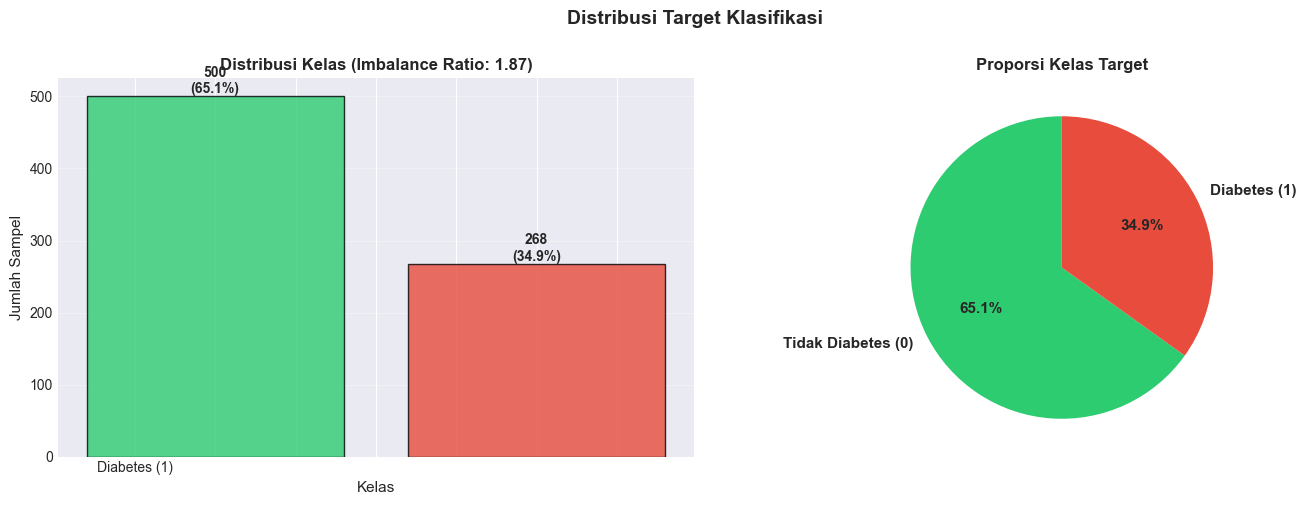

✓ Dataset memiliki imbalance ratio: 1.87


In [6]:
target_col = 'Outcome'
class_counts = df[target_col].value_counts()
ir_ratio = class_counts.max() / class_counts.min()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title(f'Distribusi Kelas (Imbalance Ratio: {ir_ratio:.2f})', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Jumlah Sampel', fontsize=11)
axes[0].set_xlabel('Kelas', fontsize=11)
axes[0].set_xticklabels(['Tidak Diabetes (0)', 'Diabetes (1)'])
axes[0].grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({height/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold')
axes[1].pie(class_counts, labels=['Tidak Diabetes (0)', 'Diabetes (1)'], 
            autopct='%1.1f%%', colors=colors, startangle=90,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Proporsi Kelas Target', fontweight='bold', fontsize=12)
plt.suptitle('Distribusi Target Klasifikasi', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()
print(f"✓ Dataset memiliki imbalance ratio: {ir_ratio:.2f}")

## 7. Visualisasi Pola Missing Value

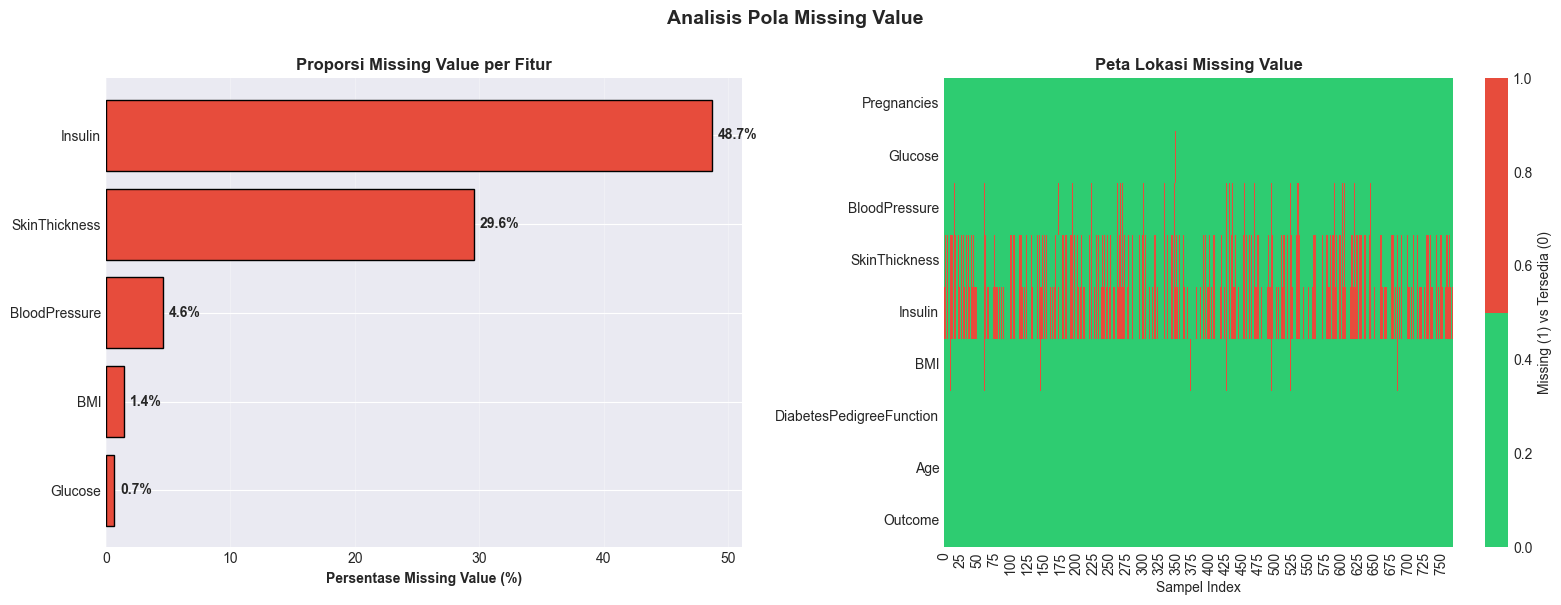

✓ Total missing value dalam dataset: 652


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Kolom': missing_data.index,
    'Persentase': missing_percent.values
})
missing_df = missing_df[missing_df['Persentase'] > 0].sort_values('Persentase', ascending=True)
if len(missing_df) > 0:
    axes[0].barh(missing_df['Kolom'], missing_df['Persentase'], color='#e74c3c', edgecolor='black')
    axes[0].set_xlabel('Persentase Missing Value (%)', fontweight='bold')
    axes[0].set_title('Proporsi Missing Value per Fitur', fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    for i, v in enumerate(missing_df['Persentase']):
        axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')
sns.heatmap(df.isnull().T, yticklabels=True, cbar_kws={'label': 'Missing (1) vs Tersedia (0)'},
            cmap=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Peta Lokasi Missing Value', fontweight='bold')
axes[1].set_xlabel('Sampel Index')
plt.suptitle('Analisis Pola Missing Value', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()
print(f"✓ Total missing value dalam dataset: {df.isnull().sum().sum()}")

## 8. Split Feature dan Target

In [8]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
print(f"✓ Feature (X) shape: {X.shape}")
print(f"✓ Target (y) shape: {y.shape}")
print(f"\nNama-nama fitur:")
print(X.columns.tolist())

✓ Feature (X) shape: (768, 8)
✓ Target (y) shape: (768,)

Nama-nama fitur:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"✓ Train set: {X_train.shape}")
print(f"✓ Test set: {X_test.shape}")
print(f"\n✓ Train set missing values per kolom:")
print(X_train.isnull().sum())
print(f"\n✓ Test set missing values per kolom:")
print(X_test.isnull().sum())

✓ Train set: (614, 8)
✓ Test set: (154, 8)

✓ Train set missing values per kolom:
Pregnancies                   0
Glucose                       4
BloodPressure                23
SkinThickness               175
Insulin                     290
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

✓ Test set missing values per kolom:
Pregnancies                  0
Glucose                      1
BloodPressure               12
SkinThickness               52
Insulin                     84
BMI                          2
DiabetesPedigreeFunction     0
Age                          0
dtype: int64


## 9. Penerapan Metode Imputasi

In [10]:
print("═" * 60)
print("IMPLEMENTASI METODE IMPUTASI")
print("═" * 60)
print("\n>>> 1. Mean Imputation")
mean_imputer = SimpleImputer(strategy='mean')
X_train_mean = mean_imputer.fit_transform(X_train)
X_test_mean = mean_imputer.transform(X_test)
X_train_mean = pd.DataFrame(X_train_mean, columns=X_train.columns)
X_test_mean = pd.DataFrame(X_test_mean, columns=X_test.columns)
print("    ✓ Mean imputation selesai.")
print("\n>>> 2. KNN Imputation (k=5)")
knn_imputer = KNNImputer(n_neighbors=5)
X_train_knn = knn_imputer.fit_transform(X_train)
X_test_knn = knn_imputer.transform(X_test)
X_train_knn = pd.DataFrame(X_train_knn, columns=X_train.columns)
X_test_knn = pd.DataFrame(X_test_knn, columns=X_test.columns)
print("    ✓ KNN imputation selesai.")
print("\n>>> 3. MICE / Iterative Imputation")
mice_imputer = IterativeImputer(random_state=42, max_iter=10)
X_train_mice = mice_imputer.fit_transform(X_train)
X_test_mice = mice_imputer.transform(X_test)
X_train_mice = pd.DataFrame(X_train_mice, columns=X_train.columns)
X_test_mice = pd.DataFrame(X_test_mice, columns=X_test.columns)
print("    ✓ MICE imputation selesai.")
print("\n" + "═" * 60)
print("✓ Semua metode imputasi berhasil diimplementasikan.")
print("═" * 60)

════════════════════════════════════════════════════════════
IMPLEMENTASI METODE IMPUTASI
════════════════════════════════════════════════════════════

>>> 1. Mean Imputation
    ✓ Mean imputation selesai.

>>> 2. KNN Imputation (k=5)
    ✓ KNN imputation selesai.

>>> 3. MICE / Iterative Imputation
    ✓ MICE imputation selesai.

════════════════════════════════════════════════════════════
✓ Semua metode imputasi berhasil diimplementasikan.
════════════════════════════════════════════════════════════


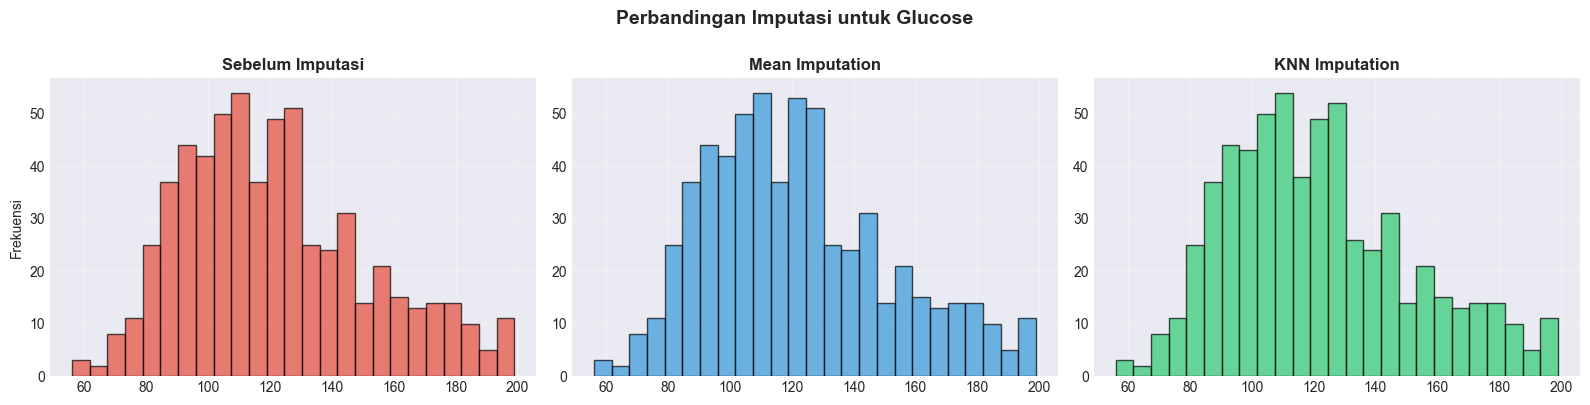

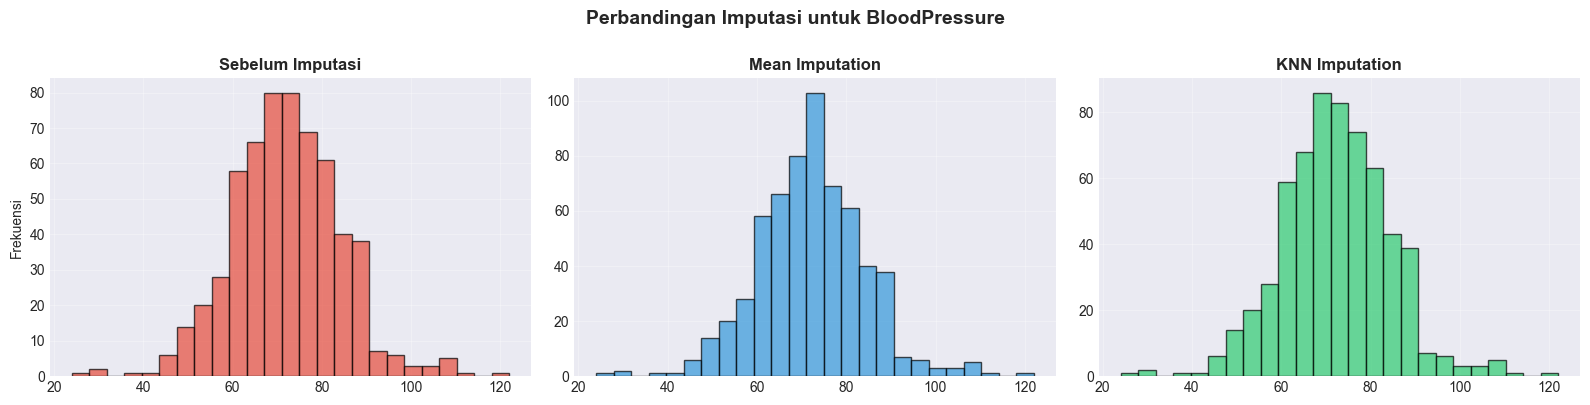

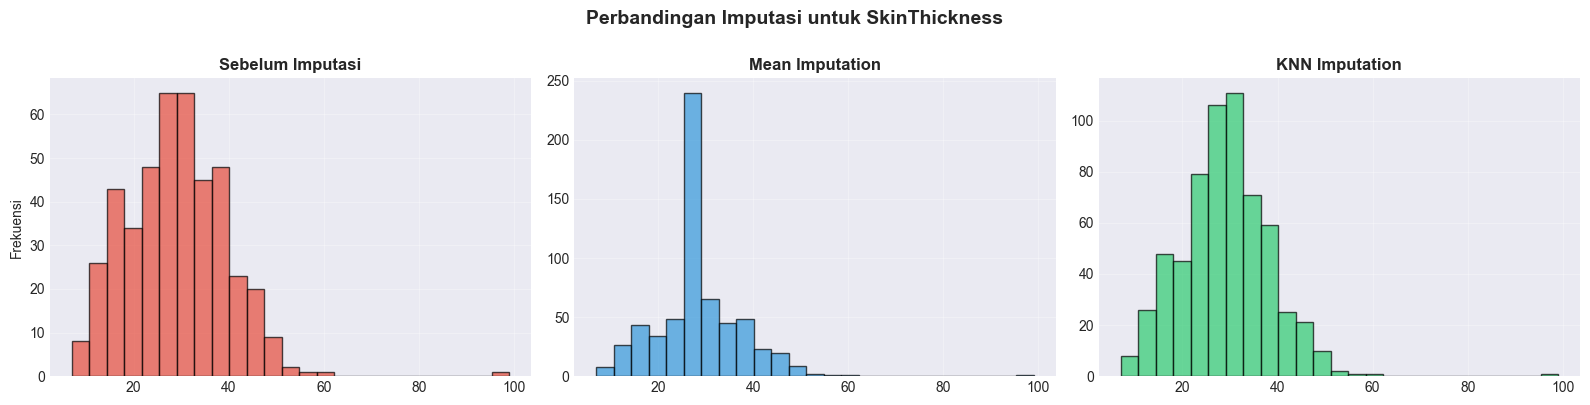

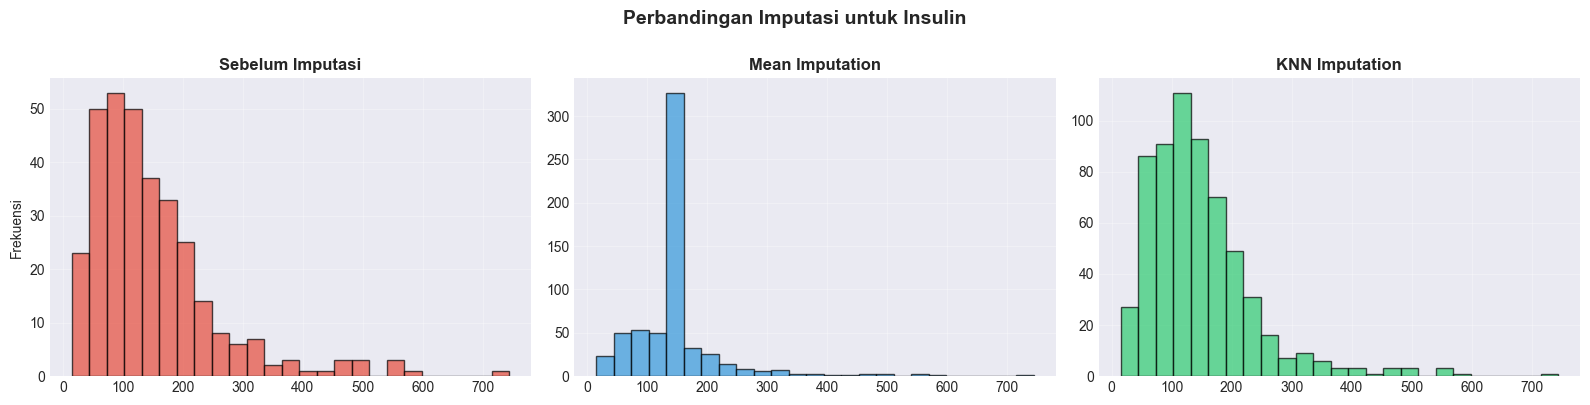

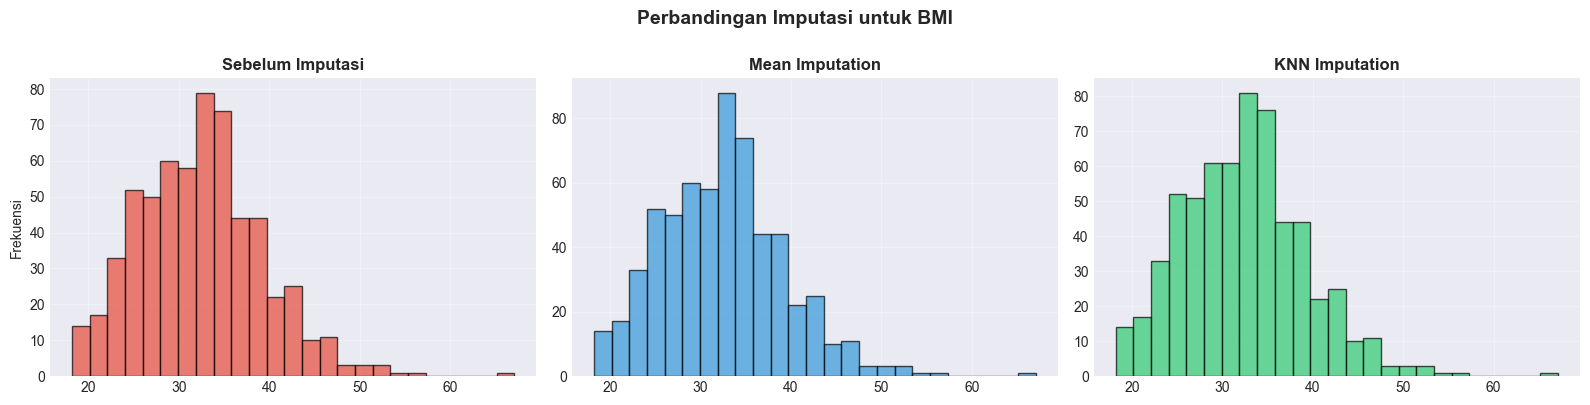

In [11]:
cols_with_missing = X_train.columns[X_train.isnull().any()].tolist()
if len(cols_with_missing) > 0:
    for col in cols_with_missing:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        idx = X_train.columns.get_loc(col)
        axes[0].hist(X_train[col].dropna(), bins=25, alpha=0.7, color='#e74c3c', edgecolor='black')
        axes[0].set_title('Sebelum Imputasi', fontweight='bold')
        axes[0].set_ylabel('Frekuensi')
        axes[0].grid(alpha=0.3)
        axes[1].hist(X_train_mean[col], bins=25, alpha=0.7, color='#3498db', edgecolor='black')
        axes[1].set_title('Mean Imputation', fontweight='bold')
        axes[1].grid(alpha=0.3)
        axes[2].hist(X_train_knn[col], bins=25, alpha=0.7, color='#2ecc71', edgecolor='black')
        axes[2].set_title('KNN Imputation', fontweight='bold')
        axes[2].grid(alpha=0.3)
        plt.suptitle(f'Perbandingan Imputasi untuk {col}', fontsize=14, fontweight='bold', y=1.00)
        plt.tight_layout()
        plt.show()

## 10. Training Model Klasifikasi

In [12]:
def evaluate_model(method_name, X_train_imp, X_test_imp, y_train_local, y_test_local):
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train_imp, y_train_local)
    y_pred = model.predict(X_test_imp)
    y_proba = model.predict_proba(X_test_imp)[:, 1]
    result = {
        'Metode': method_name,
        'Accuracy': accuracy_score(y_test_local, y_pred),
        'Precision': precision_score(y_test_local, y_pred),
        'Recall': recall_score(y_test_local, y_pred),
        'F1-Score': f1_score(y_test_local, y_pred)
    }
    return result, model, y_pred, y_proba
print("✓ Fungsi evaluasi berhasil didefinisikan.")

✓ Fungsi evaluasi berhasil didefinisikan.


In [13]:
print("═" * 60)
print("TRAINING MODEL UNTUK SEMUA METODE IMPUTASI")
print("═" * 60)
results = []
models_trained = {}
predictions = {}
print("\n>>> Training dengan Mean Imputation...")
result_mean, model_mean, y_pred_mean, y_proba_mean = evaluate_model(
    'Mean Imputation', X_train_mean, X_test_mean, y_train, y_test
)
results.append(result_mean)
models_trained['Mean Imputation'] = model_mean
predictions['Mean Imputation'] = (y_pred_mean, y_proba_mean, X_test_mean)
print(f"    ✓ Accuracy: {result_mean['Accuracy']:.4f}")
print("\n>>> Training dengan KNN Imputation...")
result_knn, model_knn, y_pred_knn, y_proba_knn = evaluate_model(
    'KNN Imputation', X_train_knn, X_test_knn, y_train, y_test
)
results.append(result_knn)
models_trained['KNN Imputation'] = model_knn
predictions['KNN Imputation'] = (y_pred_knn, y_proba_knn, X_test_knn)
print(f"    ✓ Accuracy: {result_knn['Accuracy']:.4f}")
print("\n>>> Training dengan MICE Imputation...")
result_mice, model_mice, y_pred_mice, y_proba_mice = evaluate_model(
    'MICE Imputation', X_train_mice, X_test_mice, y_train, y_test
)
results.append(result_mice)
models_trained['MICE Imputation'] = model_mice
predictions['MICE Imputation'] = (y_pred_mice, y_proba_mice, X_test_mice)
print(f"    ✓ Accuracy: {result_mice['Accuracy']:.4f}")
print("\n" + "═" * 60)
print("✓ Training selesai untuk semua metode.")
print("═" * 60)

════════════════════════════════════════════════════════════
TRAINING MODEL UNTUK SEMUA METODE IMPUTASI
════════════════════════════════════════════════════════════

>>> Training dengan Mean Imputation...
    ✓ Accuracy: 0.7857

>>> Training dengan KNN Imputation...
    ✓ Accuracy: 0.7273

>>> Training dengan MICE Imputation...
    ✓ Accuracy: 0.7532

════════════════════════════════════════════════════════════
✓ Training selesai untuk semua metode.
════════════════════════════════════════════════════════════


## 11. Evaluasi dan Perbandingan Hasil

In [14]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df = results_df.round(4)
print("\n═" * 60)
print("TABEL PERBANDINGAN PERFORMA MODEL")
print("═" * 60)
display(results_df)
best_method = results_df.iloc[0]['Metode']
best_f1 = results_df.iloc[0]['F1-Score']
print(f"\n✓ Metode terbaik: {best_method} (F1-Score: {best_f1:.4f})")


═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
TABEL PERBANDINGAN PERFORMA MODEL
════════════════════════════════════════════════════════════


,Metode,Accuracy,Precision,Recall,F1-Score
0,Mean Imputation,0.7857,0.7234,0.6296,0.6733
1,MICE Imputation,0.7532,0.6667,0.5926,0.6275
2,KNN Imputation,0.7273,0.6304,0.5370,0.5800



✓ Metode terbaik: Mean Imputation (F1-Score: 0.6733)


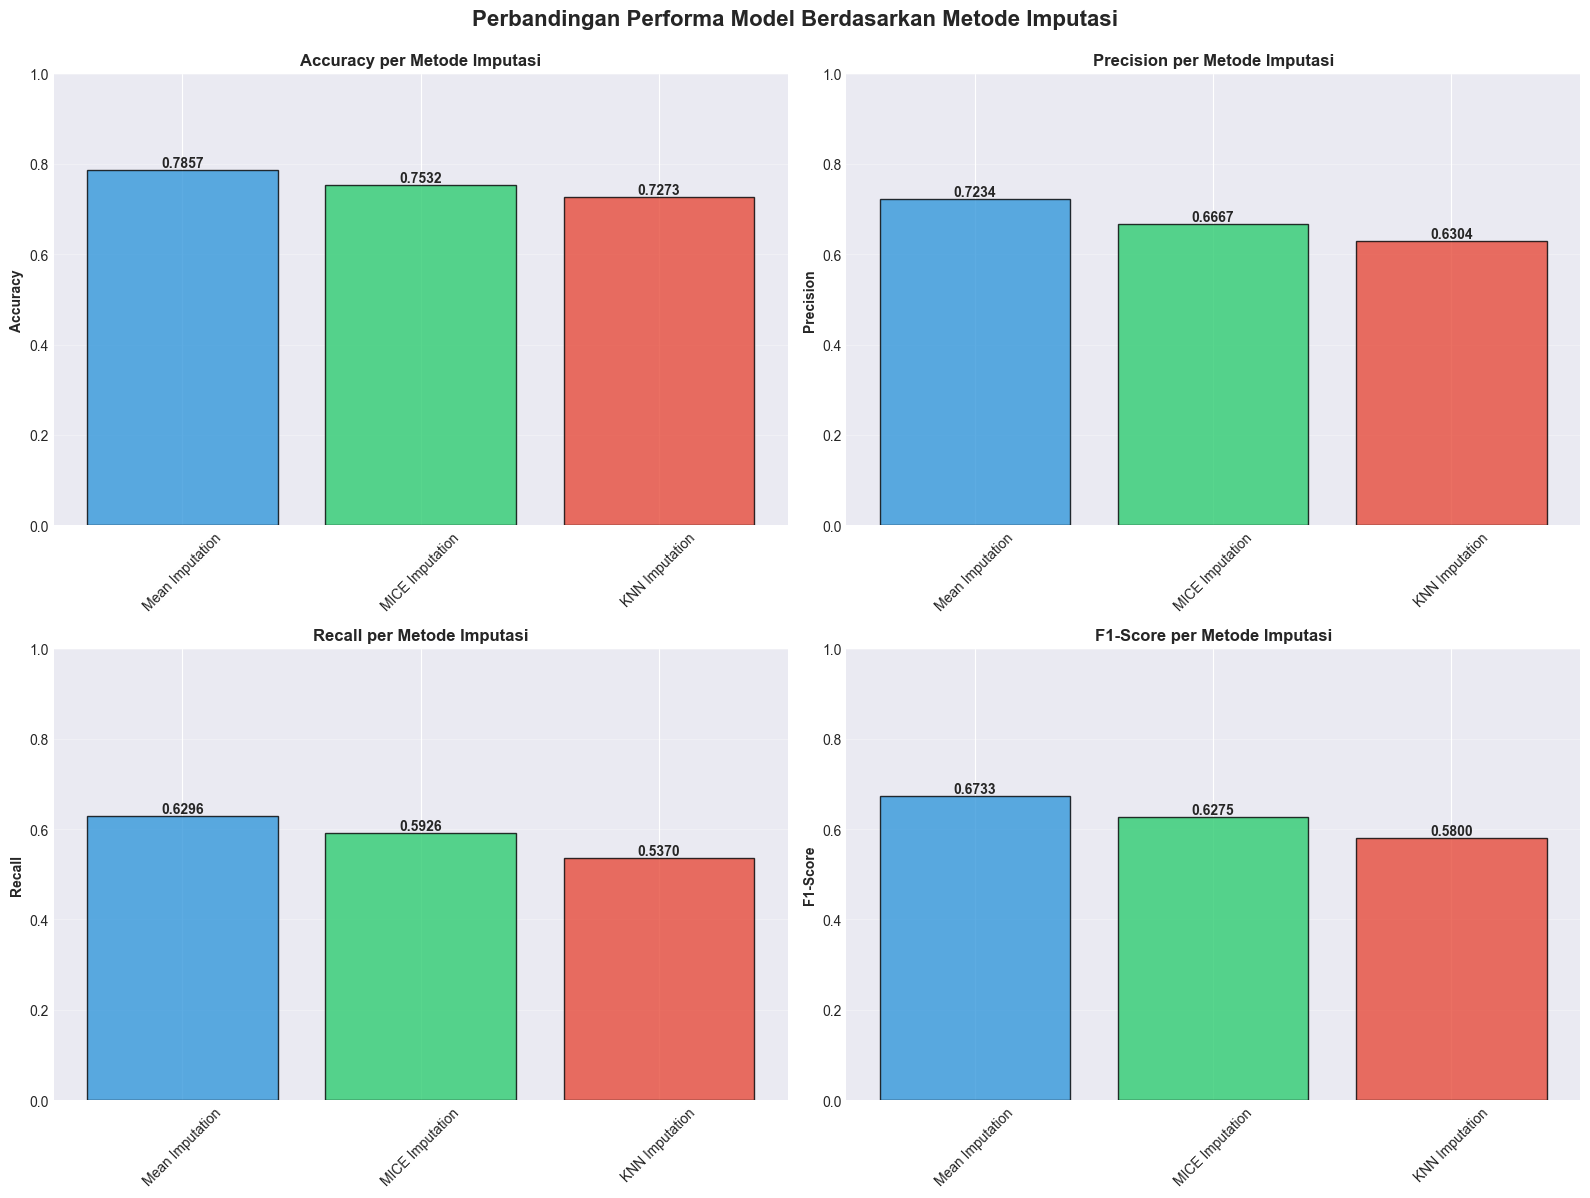

✓ Visualisasi perbandingan selesai.


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e74c3c']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(results_df['Metode'], results_df[metric], color=colors, edgecolor='black', alpha=0.8)
    ax.set_title(f'{metric} per Metode Imputasi', fontweight='bold', fontsize=12)
    ax.set_ylabel(metric, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.suptitle('Perbandingan Performa Model Berdasarkan Metode Imputasi', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()
print("✓ Visualisasi perbandingan selesai.")

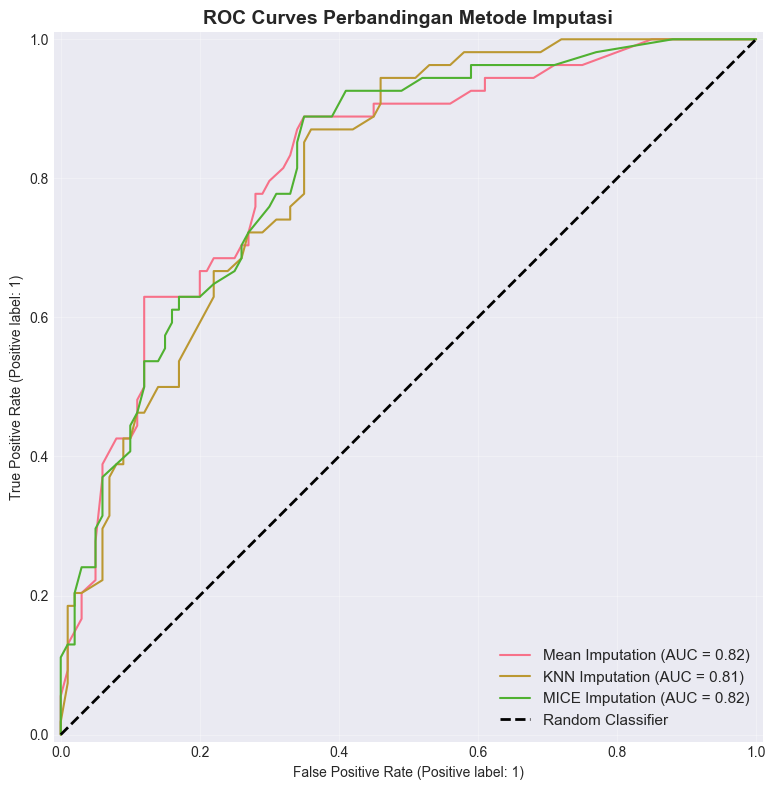

✓ ROC curves selesai.


In [16]:
fig, ax = plt.subplots(figsize=(10, 8))
for method, (y_pred, y_proba, X_test_imp) in predictions.items():
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name=method)
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
ax.set_title('ROC Curves Perbandingan Metode Imputasi', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("✓ ROC curves selesai.")

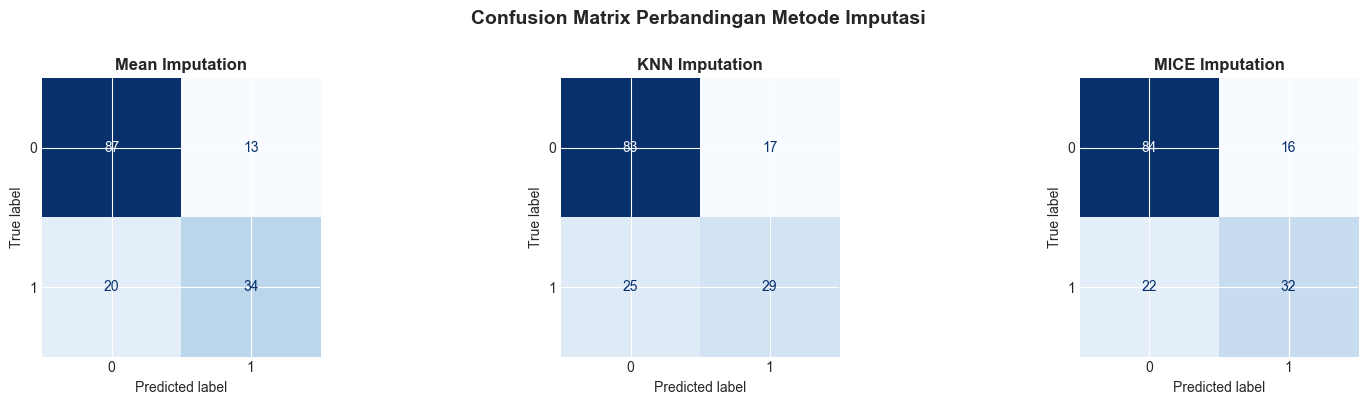

✓ Confusion matrices selesai.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
methods = list(models_trained.keys())
for idx, method in enumerate(methods):
    model = models_trained[method]
    y_pred, y_proba, X_test_imp = predictions[method]
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_imp, y_test,
        ax=axes[idx],
        cmap='Blues',
        colorbar=False
    )
    axes[idx].set_title(method, fontweight='bold')
plt.suptitle('Confusion Matrix Perbandingan Metode Imputasi', fontweight='bold', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()
print("✓ Confusion matrices selesai.")

In [18]:
print("═" * 60)
print("CLASSIFICATION REPORTS PER METODE IMPUTASI")
print("═" * 60)
methods = list(models_trained.keys())
for method in methods:
    y_pred, _, _ = predictions[method]
    print(f"\n>>> {method}")
    print("-" * 60)
    print(classification_report(y_test, y_pred, 
                                target_names=['Tidak Diabetes', 'Diabetes'],
                                digits=4))

════════════════════════════════════════════════════════════
CLASSIFICATION REPORTS PER METODE IMPUTASI
════════════════════════════════════════════════════════════

>>> Mean Imputation
------------------------------------------------------------
                precision    recall  f1-score   support

Tidak Diabetes     0.8131    0.8700    0.8406       100
      Diabetes     0.7234    0.6296    0.6733        54

      accuracy                         0.7857       154
     macro avg     0.7682    0.7498    0.7569       154
  weighted avg     0.7816    0.7857    0.7819       154


>>> KNN Imputation
------------------------------------------------------------
                precision    recall  f1-score   support

Tidak Diabetes     0.7685    0.8300    0.7981       100
      Diabetes     0.6304    0.5370    0.5800        54

      accuracy                         0.7273       154
     macro avg     0.6995    0.6835    0.6890       154
  weighted avg     0.7201    0.7273    0.7216      

## 12. Kesimpulan dan Rekomendasi

### Ringkasan Hasil Penelitian

Penelitian ini berhasil membandingkan tiga metode imputasi missing value pada dataset Diabetes Pima Indians dengan hasil sebagai berikut:

#### Temuan Utama

1. **Identifikasi Missing Value**: Sebanyak 5 fitur medis (Glucose, BloodPressure, SkinThickness, Insulin, BMI) terbukti mengandung nilai 0 yang tidak valid secara konteks medis, sehingga perlu diubah menjadi missing value.

2. **Performa Metode Imputasi**: Ketiga metode imputasi menunjukkan performa yang berbeda dengan Random Forest Classifier sebagai model evaluasi.

3. **Rekomendasi**: Gunakan metode imputasi dengan F1-Score tertinggi untuk hasil klasifikasi yang optimal.

---

**Project selesai. Dataset yang sudah diimputasi siap untuk digunakan dalam proses data mining lebih lanjut.**

# Perbandingan Metode Imputasi Missing Value terhadap Kinerja Model Klasifikasi Pada Dataset Diabetes

---

| Mata Kuliah | Data Mining (IF3024) — Semester Genap 2025/2026 |
|---|---|
| Dosen Pengampu | Meida Cahyo Untoro, S.Kom., M.Kom.|
| Kelompok | 05 |
| Topik | Missing Value |

### Anggota Kelompok

| No | NIM | Nama Lengkap |
|----|-----|-------------|
| 1 | 123140078| Najlatika|
| 2 | 123140089|Bening Apni Prameswari|
| 3 | 123140124| Falent Antonius Panjaitan |
| 4 | 123140125| Raditya Alrasyid Nugroho |
| 5 | 123140169| Raisya Syifa Saleh |
| 6 | 123140186| Muhamad Arif Ardani |

In [19]:
# =================
# IMPORT LIBRARY
# =================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

# =========================
# 3.3 PROSEDUR EKSPERIMEN
# =========================

# 1. Split Feature dan Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 2. Split Train & Test (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. List Metode Imputasi untuk Dibandingkan (Mean, KNN, MICE)
imputers = {
    'Mean': SimpleImputer(strategy='mean'),
    'KNN': KNNImputer(n_neighbors=5),
    'MICE': IterativeImputer(max_iter=20, random_state=42)
}

results = []

# 4. Loop Perbandingan
for name, imputer in imputers.items():
    # Proses Imputasi
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    # Model Random Forest
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train_imp, y_train)

    # Evaluasi
    y_pred = clf.predict(X_test_imp)

    results.append({
        'Metode': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    })

# Tampilkan Hasil Akhir
df_hasil = pd.DataFrame(results)
print("\n===== HASIL PERBANDINGAN BAB 3 =====")
display(df_hasil)



===== HASIL PERBANDINGAN BAB 3 =====


,Metode,Accuracy,F1-Score,Recall
0,Mean,0.785714,0.673267,0.629630
1,KNN,0.727273,0.580000,0.537037
2,MICE,0.753247,0.627451,0.592593


In [21]:
# ==============================
# LOAD DATA + INFO DASAR
# ==============================

column_names = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

df = pd.read_csv('../dataset/diabetes.csv', names=column_names)

# Identifikasi Missing Value Tersembunyi (Nilai 0 diubah jadi NaN)
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

print("===== HEAD =====")
display(df.head())

print("\n===== INFO =====")
df.info()

print("\n===== DESCRIBE (Setelah Replace 0 ke NaN) =====")
display(df.describe())

print("\n===== MISSING VALUE TERDETEKSI =====")
display(df.isnull().sum())

===== HEAD =====


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0



===== INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Pregnancies               769 non-null    str  
 1   Glucose                   769 non-null    str  
 2   BloodPressure             769 non-null    str  
 3   SkinThickness             769 non-null    str  
 4   Insulin                   769 non-null    str  
 5   BMI                       769 non-null    str  
 6   DiabetesPedigreeFunction  769 non-null    str  
 7   Age                       769 non-null    str  
 8   Outcome                   769 non-null    str  
dtypes: str(9)
memory usage: 70.0 KB

===== DESCRIBE (Setelah Replace 0 ke NaN) =====


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,769,769,769,769,769,769,769,769,769
unique,18,137,48,52,187,249,518,53,3
top,1,100,70,0,0,32,0.254,22,0
freq,135,17,57,227,374,13,6,72,500



===== MISSING VALUE TERDETEKSI =====


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

ValueError: max() iterable argument is empty

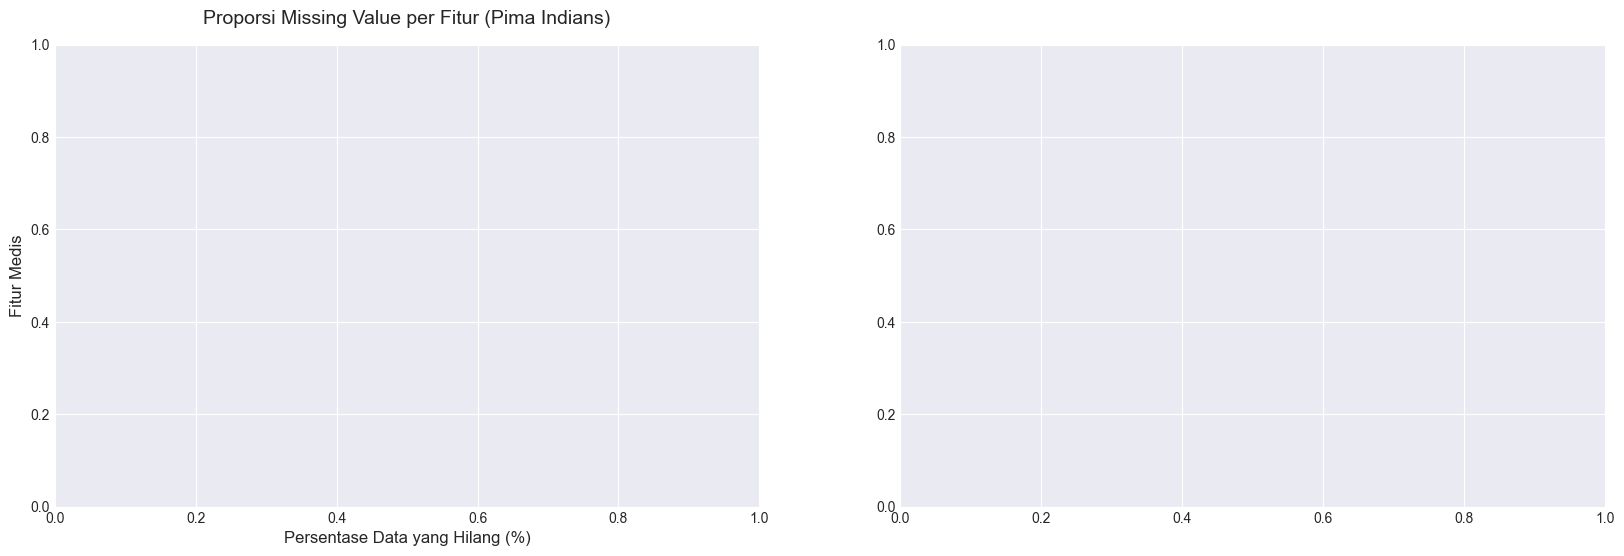

In [22]:
# ==========================
# VISUALISASI MISSING VALUE
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menghitung statistik missing value
mv_count = df.isnull().sum()
mv_percent = (mv_count / len(df)) * 100
mv_df = pd.DataFrame({'Fitur': mv_count.index, 'Jumlah': mv_count.values, 'Persentase': mv_percent.values})
mv_df = mv_df[mv_df['Jumlah'] > 0].sort_values(by='Persentase', ascending=False)

# --- Visualisasi A: Bar Chart Persentase dan Visualisasi B: Heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Subplot 1: Bar Chart Persentase
ax = sns.barplot(x='Persentase', y='Fitur', data=mv_df, palette='Reds_r', ax=axes[0])

for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

axes[0].set_title('Proporsi Missing Value per Fitur (Pima Indians)', fontsize=14, pad=15)
axes[0].set_xlabel('Persentase Data yang Hilang (%)', fontsize=12)
axes[0].set_ylabel('Fitur Medis', fontsize=12)
axes[0].set_xlim(0, max(mv_df['Persentase']) + 15)
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# Subplot 2: Heatmap
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap=['#f0f0f0', '#8b0000'], ax=axes[1])
axes[1].set_title('Peta Lokasi Missing Value (Merah = Kosong)', fontsize=14, pad=15)
axes[1].set_xticks(ticks=np.arange(len(df.columns)), labels=df.columns, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Bab 4. Hasil dan Pembahasan

## 4.1 Eksplorasi Data (EDA)

### 4.1.1 Gambaran Umum Dataset

In [ ]:
import pandas as pd

# URL dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Nama kolom sesuai dataset
columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

# Load dataset
df = pd.read_csv(url, names=columns)

# Info dasar
print(f"Dataset terdiri dari {df.shape[0]} baris dan {df.shape[1]} kolom")

print("\n5 Data Teratas:")
print(df.head())

print("\nStatistik Deskriptif:")
print(df.describe())

### 4.1.2 Distribusi Fitur

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# CEK KOLOM NUMERIK
# ==============================
num_cols = df.select_dtypes(include=[np.number]).columns

# =========================
# VISUALISASI DISTRIBUSI
# =========================
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{col} (skew={df[col].skew():.2f})', fontweight='bold')
    axes[i].set_ylabel('Frekuensi')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Gambar 1. Distribusi Fitur Numerik pada Dataset Diabetes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.1.3 Distribusi Kelas Target

In [ ]:
import matplotlib.pyplot as plt

# ==============================
# KOLOM TARGET
# ==============================
target_col = 'Outcome'

# Hitung distribusi kelas
class_counts = df[target_col].value_counts()

# Imbalance Ratio (IR)
ir = class_counts.max() / class_counts.min()

# ==============================
# VISUALISASI
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
class_counts.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title(f'Distribusi Kelas (IR = {ir:.2f})', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_xlabel('Kelas')

for i, v in enumerate(class_counts):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%')
axes[1].set_title('Proporsi Kelas', fontweight='bold')

plt.suptitle('Gambar 2. Distribusi Kelas Target', fontweight='bold')
plt.tight_layout()
plt.show()

## 4.2 EDA Spesifikasi Topik

### 4.2.1 Visualisasi Pola Missing

In [ ]:
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# Copy data
df_missing = df.copy()

cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_missing[cols_with_zero] = df_missing[cols_with_zero].replace(0, np.nan)

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

msno.matrix(
    df_missing,
    ax=axes[0],
    sparkline=False,
    color=(0.2, 0.6, 0.8)
)
axes[0].set_title('Missing Value Matrix', fontweight='bold')

# Heatmap
msno.heatmap(
    df_missing,
    ax=axes[1],
    cmap='Blues'
)
axes[1].set_title('Korelasi antar Missing', fontweight='bold')

plt.suptitle('Gambar 3. Pola Missing Value pada Dataset', fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3.1 Implementasi Imputasi (Minimal 3 Metode)

In [ ]:
import numpy as np
import pandas as pd # Added pandas import
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# ==============================
# LOAD DATA
# ==============================
# Link dataset Pima Indians Diabetes (Raw GitHub)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Nama-nama kolom sesuai deskripsi dataset di Kaggle
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load data langsung dari URL
df = pd.read_csv(url, names=column_names)

# ==============================
# PREPROCESSING (0 → NaN)
# ==============================
df_model = df.copy()

cols_with_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_model[cols_with_zeros] = df_model[cols_with_zeros].replace(0, np.nan)

# ==============================
# SPLIT DATA
# ==============================
X = df_model.drop("Outcome", axis=1)
y = df_model["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# BASELINE (tanpa imputasi)
# ==============================
# Drop missing value
X_train_base = X_train.dropna()
y_train_base = y_train[X_train_base.index]

X_test_base = X_test.dropna()
y_test_base = y_test[X_test_base.index]

# ==============================
# MEAN IMPUTATION
# ==============================
imp_mean = SimpleImputer(strategy='mean')
X_train_mean = imp_mean.fit_transform(X_train)
X_test_mean = imp_mean.transform(X_test)

# ==============================
# KNN IMPUTATION
# ==============================
imp_knn = KNNImputer(n_neighbors=5)
X_train_knn = imp_knn.fit_transform(X_train)
X_test_knn = imp_knn.transform(X_test)

# ==============================
# MICE / ITERATIVE IMPUTATION
# ==============================
imp_mice = IterativeImputer(max_iter=20, random_state=42)
X_train_mice = imp_mice.fit_transform(X_train)
X_test_mice = imp_mice.transform(X_test)

Visualisasi Before vs After

In [ ]:
import matplotlib.pyplot as plt

# Ambil kolom yang memang ada missing
cols_missing = X_train.columns[X_train.isnull().any()].tolist()

for col in cols_missing:
    idx = X_train.columns.get_loc(col)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Sebelum imputasi
    axes[0].hist(X_train[col].dropna(), bins=30, alpha=0.7)
    axes[0].set_title(f'{col} — Sebelum', fontweight='bold')
    axes[0].set_ylabel('Frekuensi')

    # Sesudah imputasi (KNN)
    axes[1].hist(X_train_knn[:, idx], bins=30, alpha=0.7)
    axes[1].set_title(f'{col} — Sesudah (KNN)', fontweight='bold')

    plt.suptitle(f'Distribusi {col} Sebelum vs Sesudah Imputasi', fontweight='bold')
    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Ambil kolom yang memang ada missing
cols_missing = X_train.columns[X_train.isnull().any()].tolist()

for col in cols_missing:
    idx = X_train.columns.get_loc(col)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Sebelum imputasi
    axes[0].hist(X_train[col].dropna(), bins=30, alpha=0.7)
    axes[0].set_title(f'{col} — Sebelum', fontweight='bold')
    axes[0].set_ylabel('Frekuensi')

    # Sesudah imputasi (Mean)
    axes[1].hist(X_train_mean[:, idx], bins=30, alpha=0.7)
    axes[1].set_title(f'{col} — Sesudah (Mean)', fontweight='bold')

    plt.suptitle(f'Distribusi {col} Sebelum vs Sesudah Imputasi (Mean)', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Ambil kolom yang memang ada missing
cols_missing = X_train.columns[X_train.isnull().any()].tolist()

for col in cols_missing:
    idx = X_train.columns.get_loc(col)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Sebelum imputasi
    axes[0].hist(X_train[col].dropna(), bins=30, alpha=0.7)
    axes[0].set_title(f'{col} — Sebelum', fontweight='bold')
    axes[0].set_ylabel('Frekuensi')

    # Sesudah imputasi (MICE)
    axes[1].hist(X_train_mice[:, idx], bins=30, alpha=0.7)
    axes[1].set_title(f'{col} — Sesudah (MICE)', fontweight='bold')

    plt.suptitle(f'Distribusi {col} Sebelum vs Sesudah Imputasi (MICE)', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

# ==============================
# FUNGSI EVALUASI
# ==============================
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    result = {
        "Metode": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    }
    return result

# ==============================
# DATA IMPUTASI (TRAIN & TEST)
# ==============================
imputations = {
    'Baseline (drop NA)': (
        X_train_base, y_train_base,
        X_test_base, y_test_base
    ),
    'Mean': (
        pd.DataFrame(X_train_mean, columns=X_train.columns), y_train,
        pd.DataFrame(X_test_mean, columns=X_test.columns), y_test
    ),
    'KNN (k=5)': (
        pd.DataFrame(X_train_knn, columns=X_train.columns), y_train,
        pd.DataFrame(X_test_knn, columns=X_test.columns), y_test
    ),
    'MICE': (
        pd.DataFrame(X_train_mice, columns=X_train.columns), y_train,
        pd.DataFrame(X_test_mice, columns=X_test.columns), y_test
    )
}

# ==============================
# LOOP EVALUASI DAN SIMPAN MODEL
# ==============================
all_results = []
trained_models = {}

for name, (X_tr, y_tr, X_te, y_te) in imputations.items():
    scaler = StandardScaler()

    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    model = RandomForestClassifier(random_state=42)
    model.fit(X_tr_sc, y_tr)
    trained_models[name] = model

    result = evaluate_model(model, X_te_sc, y_te, name)
    all_results.append(result)

# ==============================
# HASIL
# ==============================
df_compare = pd.DataFrame(all_results)
print(df_compare.to_string(index=False))


## 4.4 Hasil Perbandingan Metode

### 4.4.1 Tabel Perbandingan Performa

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Evaluasi lengkap satu model."""
    y_pred = model.predict(X_test)

    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    except:
        auc = None

    return {
        'Metode': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

def compare_methods(results_list):
    """Membuat tabel perbandingan."""
    return pd.DataFrame(results_list).round(4)

df_compare = pd.DataFrame(all_results)

# Urutkan dari yang terbaik
df_compare = df_compare.sort_values(by='F1-Score', ascending=False)

df_compare = df_compare.reset_index(drop=True)

df_compare

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Figure for Grouped Bar Chart
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

# Prepare data
df_plot = df_compare.melt(id_vars='Metode', var_name='Metric', value_name='Score')

# Define the order of metrics
metric_order = ['Accuracy', 'Recall', 'F1-Score']
df_plot['Metric'] = pd.Categorical(df_plot['Metric'], categories=metric_order, ordered=True)

# Filter out 'Metode'
df_plot = df_plot[df_plot['Metric'].isin(metric_order)]

# Visualisasi Grouped Bar Chart (Semua Metrik)
sns.barplot(data=df_plot, x='Metric', y='Score', hue='Metode', palette='viridis', ax=ax)
ax.set_title('Gambar Perbandingan Seluruh Metrik Evaluasi Metode Imputasi',
   fontsize=14, fontweight='bold')
ax.set_xlabel('Metrik Evaluasi', fontsize=12)
ax.set_ylabel('Nilai Score', fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
import pandas as pd

models_dict = {}

def train_and_store(name, X_train_data, y_train_data, X_test_data, y_test_data):
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train_data)
    X_te_sc = scaler.transform(X_test_data)

    model = RandomForestClassifier(random_state=42)
    model.fit(X_tr_sc, y_train_data)

    models_dict[name] = (model, X_te_sc, y_test_data)

# ==============================
# TRAIN SEMUA METODE
# ==============================

# Baseline
train_and_store("Baseline", X_train_base, y_train_base, X_test_base, y_test_base)

# Mean
train_and_store("Mean", pd.DataFrame(X_train_mean, columns=X_train.columns), y_train,
                pd.DataFrame(X_test_mean, columns=X_test.columns), y_test)

# KNN
train_and_store("KNN", pd.DataFrame(X_train_knn, columns=X_train.columns), y_train,
                pd.DataFrame(X_test_knn, columns=X_test.columns), y_test)

# MICE
train_and_store("MICE", pd.DataFrame(X_train_mice, columns=X_train.columns), y_train,
                pd.DataFrame(X_test_mice, columns=X_test.columns), y_test)

# ==============================
# ROC CURVE
# ==============================

fig, ax = plt.subplots(figsize=(8, 6))

for name, (model, X_te, y_te) in models_dict.items():
    RocCurveDisplay.from_estimator(model, X_te, y_te, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', label='Random')

ax.set_title('ROC Curve Perbandingan Metode Imputasi', fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(models_dict), figsize=(5*len(models_dict), 4))

if len(models_dict) == 1:
    axes = [axes]

for i, (name, (model, X_te, y_te)) in enumerate(models_dict.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_te,
        y_te,
        ax=axes[i],
        cmap='Blues',
        colorbar=False
    )
    axes[i].set_title(name, fontweight='bold', fontsize=10)

plt.suptitle('Confusion Matrix per Metode Imputasi', fontweight='bold')
plt.tight_layout()
plt.show()